==========================================================
## 객체(사람)탐지/행동감지 영상분석 프로젝트
==========================================================

In [14]:
# 딥러닝 프레임워크
# !pip install tensorflow==2.15.0
# !pip install keras

# 영상 처리
# !pip install opencv-python

# 수치 계산
# !pip install numpy==1.26.4
# !pip install numpy==1.26.4 opencv-python==4.8.1.78 --force-reinstall

# 행동 분석 (포즈 분석)
# !pip install mediapipe==0.10.9

# 데이터 직렬화
# !pip install protobuf==4.25.3

# 데이터 전처리
# !pip install scikit-learn==1.3.2

# 데이터 시각화
# !pip install matplotlib
# !pip install seaborn

# 진행 상황 표시
# !pip install tqdm

# YOLO 영상속 객체 탐지
# !pip install ultralytics

# 다중 객체 추적
# !pip install deep-sort-realtime "numpy==1.26.4"

In [43]:
# 라이브러리 버전 확인

import numpy as np
import mediapipe as mp
import tensorflow as tf
import cv2

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import sklearn

print("sklearn:", sklearn.__version__)
print("numpy:", np.__version__)
print("mediapipe:", mp.__version__)
print("tensorflow:", tf.__version__)
print("cv2:", cv2.__version__)

sklearn: 1.3.2
numpy: 1.26.4
mediapipe: 0.10.9
tensorflow: 2.15.0
cv2: 4.8.1


In [1]:
# 키포인트 추출 (크롭 방식)
import cv2
import mediapipe as mp
import numpy as np
import os

mp_pose = mp.solutions.pose
SEQUENCE_LEN = 15  # ← 전체 파이프라인 공통 상수

label_map = {}
for i in range(1, 28): label_map[f'run_{i:02d}']   = 'run'
for i in range(1, 24): label_map[f'stand_{i:02d}'] = 'stand'
for i in range(1, 26): label_map[f'walk_{i:02d}']  = 'walk'

video_dir = './video'

# ─────────────────────────────────────────
# 핵심 : 영상 전체 프레임이 아닌
# 가장 큰 사람 박스를 크롭해서 포즈 추출
# ─────────────────────────────────────────
from ultralytics import YOLO
yolo = YOLO('yolo11n.pt')

def extract_keypoints_crop(frame, pose):
    # YOLO로 사람 찾고 크롭 후 포즈 추출 → 추론 코드와 동일한 방식
    H, W = frame.shape[:2]
    results = yolo(frame, classes=0, conf=0.5, verbose=False)
    
    # 가장 큰 사람 박스 선택
    main_box = None
    max_area = 0
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        area = (x2-x1)*(y2-y1)
        if area > max_area:
            max_area = area
            main_box = (x1, y1, x2, y2)

    if main_box is None:
        return None

    x1, y1, x2, y2 = main_box
    pad = 20
    cx1, cy1 = max(0, x1-pad), max(0, y1-pad)
    cx2, cy2 = min(W, x2+pad), min(H, y2+pad)

    crop = frame[cy1:cy2, cx1:cx2]
    if crop.size == 0:
        return None

    rgb_crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    result = pose.process(rgb_crop)

    if not result.pose_landmarks:
        return None

    # 크롭 좌표 → 전체 프레임 기준으로 재정규화 (추론 코드와 동일하게)
    kp = []
    for lm in result.pose_landmarks.landmark:
        abs_x = lm.x * (cx2 - cx1) + cx1
        abs_y = lm.y * (cy2 - cy1) + cy1
        kp.extend([abs_x / W, abs_y / H, lm.z, lm.visibility])

    return np.array(kp, dtype=np.float32)


# ─────────────────────────────────────────
# 시퀀스 단위로 저장 (video_id 함께 저장)
# ─────────────────────────────────────────
data   = []   # 프레임별 키포인트
labels = []
video_ids = []  # 어느 영상 출처인지 (GroupSplit용)

with mp_pose.Pose(
    model_complexity=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as pose:
    for vid_idx, (filename, label) in enumerate(label_map.items()):
        video_path = os.path.join(video_dir, filename + '.mp4')
        if not os.path.exists(video_path):
            print(f"⚠️  파일 없음: {filename}")
            continue

        cap = cv2.VideoCapture(video_path)
        frame_count = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            kp = extract_keypoints_crop(frame, pose)
            if kp is not None:
                data.append(kp)
                labels.append(label)
                video_ids.append(vid_idx)   # ← 영상 ID 저장
                frame_count += 1
        cap.release()
        print(f"✅ {filename} ({label}): {frame_count}프레임")

data      = np.array(data)
labels    = np.array(labels)
video_ids = np.array(video_ids)

print(f"\n=== 클래스별 프레임 수 ===")
for lbl in np.unique(labels):
    print(f"  {lbl}: {np.sum(labels == lbl)}프레임")
print(f"총 {len(data)}프레임")

os.makedirs('./pose_fps', exist_ok=True)
np.save('./pose_fps/data_pose.npy',   data)
np.save('./pose_fps/labels_pose.npy', labels)
np.save('./pose_fps/video_ids.npy',   video_ids)
print("💾 저장 완료")


✅ run_01 (run): 293프레임
✅ run_02 (run): 301프레임
✅ run_03 (run): 421프레임
✅ run_04 (run): 301프레임
✅ run_05 (run): 175프레임
✅ run_06 (run): 206프레임
✅ run_07 (run): 724프레임
✅ run_08 (run): 724프레임
✅ run_09 (run): 481프레임
✅ run_10 (run): 1393프레임
✅ run_11 (run): 120프레임
✅ run_12 (run): 537프레임
✅ run_13 (run): 456프레임
✅ run_14 (run): 588프레임
✅ run_15 (run): 200프레임
✅ run_16 (run): 258프레임
✅ run_17 (run): 128프레임
✅ run_18 (run): 200프레임
✅ run_19 (run): 116프레임
✅ run_20 (run): 524프레임
✅ run_21 (run): 301프레임
✅ run_22 (run): 240프레임
✅ run_23 (run): 833프레임
✅ run_24 (run): 1130프레임
✅ run_25 (run): 160프레임
✅ run_26 (run): 856프레임
✅ run_27 (run): 96프레임
✅ stand_01 (stand): 397프레임
✅ stand_02 (stand): 258프레임
✅ stand_03 (stand): 336프레임
✅ stand_04 (stand): 450프레임
✅ stand_05 (stand): 400프레임
✅ stand_06 (stand): 366프레임
✅ stand_07 (stand): 666프레임
✅ stand_08 (stand): 999프레임
✅ stand_09 (stand): 243프레임
✅ stand_10 (stand): 310프레임
✅ stand_11 (stand): 704프레임
✅ stand_12 (stand): 293프레임
✅ stand_13 (stand): 577프레임
✅ stand_14 (stand): 216프레임

In [2]:
# 데이터 증강
import numpy as np

data = np.load('./pose_fps/data_pose.npy')
labels = np.load('./pose_fps/labels_pose.npy')
video_ids = np.load('./pose_fps/video_ids.npy')

# MediaPipe 좌우 대칭 관절 쌍 (인덱스)
FLIP_PAIRS = [
    (11,12),(13,14),(15,16),   # 어깨 팔꿈치 손목
    (23,24),(25,26),(27,28),   # 엉덩이 무릎 발목
    (17,18),(19,20),(21,22),   # 손가락
    (7,8),(9,10)               # 눈 귀
]

def augment_pose(kp):
    aug = kp.copy()

    # 1) 좌우 반전
    if np.random.rand() < 0.5:
        aug[0::4] = 1.0 - aug[0::4]   # x 좌표 반전
        for l, r in FLIP_PAIRS:
            li, ri = l*4, r*4
            aug[li:li+4], aug[ri:ri+4] = aug[ri:ri+4].copy(), aug[li:li+4].copy()

    # 2) 미세 노이즈
    aug += np.random.normal(0, 0.008, aug.shape)

    # 3) 전체 스케일 (체형 차이 시뮬레이션)
    aug *= np.random.uniform(0.92, 1.08)

    # 4) 위치 이동 (카메라 위치 차이)
    aug[0::4] += np.random.uniform(-0.05, 0.05)  # x shift
    aug[1::4] += np.random.uniform(-0.05, 0.05)  # y shift
    aug = np.clip(aug, 0, 1)

    return aug.astype(np.float32)


# 클래스 불균형 고려한 증강 배수
augment_multiplier = {'walk': 2, 'run': 1,'stand': 1}

aug_data = list(data)
aug_labels = list(labels)
aug_video_ids = list(video_ids)

for label in np.unique(labels):
    idx = np.where(labels == label)[0]
    m = augment_multiplier.get(label, 2)
    for _ in range(m - 1):
        for i in idx:
            aug_data.append(augment_pose(data[i]))
            aug_labels.append(label)
            aug_video_ids.append(video_ids[i])   # video_id 유지

aug_data = np.array(aug_data)
aug_labels = np.array(aug_labels)
aug_video_ids = np.array(aug_video_ids)

print("=== 증강 후 클래스별 프레임 수 ===")
for lbl in np.unique(aug_labels):
    print(f"  {lbl}: {np.sum(aug_labels == lbl)}")
print(f"총 {len(aug_data)}프레임")

np.save('./pose_fps/aug_data.npy', aug_data)
np.save('./pose_fps/aug_labels.npy', aug_labels)
np.save('./pose_fps/aug_video_ids.npy', aug_video_ids)
print("💾 저장 완료")

=== 증강 후 클래스별 프레임 수 ===
  run: 11762
  stand: 9446
  walk: 15604
총 36812프레임
💾 저장 완료


In [2]:
# 모델 학습

import numpy as np
import pickle
import tensorflow as tf
from collections import defaultdict
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import os

SEQUENCE_LEN = 15

aug_data      = np.load('./pose_fps/aug_data.npy')
aug_labels    = np.load('./pose_fps/aug_labels.npy')
aug_video_ids = np.load('./pose_fps/aug_video_ids.npy')

def make_sequences(frames, labels, video_ids, seq_len):
    X_seq, y_seq, groups = [], [], []
    for vid in np.unique(video_ids):
        mask = np.where(video_ids == vid)[0]
        vf = frames[mask]
        vl = labels[mask]
        n  = len(vf)
        if n < seq_len:
            continue
        indices     = np.arange(seq_len)[None, :] + np.arange(n - seq_len + 1)[:, None]
        windows_f   = vf[indices]
        windows_l   = vl[indices]
        first_label = windows_l[:, 0]
        all_same    = np.all(windows_l == first_label[:, None], axis=1)
        valid       = np.where(all_same)[0]
        if len(valid) == 0:
            continue
        X_seq.append(windows_f[valid])
        y_seq.extend(windows_l[valid, -1].tolist())
        groups.extend([vid] * len(valid))
    X_seq = np.concatenate(X_seq, axis=0)
    return X_seq, np.array(y_seq), np.array(groups)

le          = LabelEncoder()
y_enc       = le.fit_transform(aug_labels)
num_classes = len(le.classes_)

X_seq, y_seq, groups = make_sequences(aug_data, y_enc, aug_video_ids, SEQUENCE_LEN)
print(f"시퀀스 수: {len(X_seq)}, shape: {X_seq.shape}")
print(f"클래스: {le.classes_}")

# 클래스별 영상 단위 split
train_idx_list = []
val_idx_list   = []

class_to_vids = defaultdict(set)
for i, (g, y) in enumerate(zip(groups, y_seq)):
    class_to_vids[y].add(g)

np.random.seed(21)
for cls, vids in class_to_vids.items():
    vids = np.array(sorted(vids))
    np.random.shuffle(vids)
    n_val      = max(1, int(len(vids) * 0.2))
    val_vids   = set(vids[:n_val])
    train_vids = set(vids[n_val:])
    for i, g in enumerate(groups):
        if y_seq[i] != cls:
            continue
        if g in val_vids:
            val_idx_list.append(i)
        else:
            train_idx_list.append(i)

train_idx = np.array(train_idx_list)
val_idx   = np.array(val_idx_list)

X_train, X_val = X_seq[train_idx], X_seq[val_idx]
y_train, y_val = y_seq[train_idx], y_seq[val_idx]
print(f"학습: {len(X_train)} / 검증: {len(X_val)}")

print("\n=== 클래스 분포 확인 ===")
for cls in sorted(np.unique(y_seq)):
    name = le.inverse_transform([cls])[0]
    tr   = np.sum(y_train == cls)
    va   = np.sum(y_val   == cls)
    print(f"  {name}: 학습 {tr} / 검증 {va}")

# 키포인트 차이 확인
print("\n=== 학습셋 vs 검증셋 키포인트 평균 비교 ===")
all_ok = True
for cls in sorted(np.unique(y_seq)):
    name    = le.inverse_transform([cls])[0]
    tr_mean = X_train[y_train == cls].mean()
    va_mean = X_val[y_val == cls].mean()
    diff    = abs(tr_mean - va_mean)
    flag    = "⚠️ 차이 큼" if diff > 0.05 else "✅"
    if diff > 0.05:
        all_ok = False
    print(f"  {name}: 학습 {tr_mean:.4f} / 검증 {va_mean:.4f} / 차이 {diff:.4f} {flag}")
if not all_ok:
    print("⚠️ 차이 큰 클래스 있음 → seed 변경 필요")
else:
    print("✅ 모든 클래스 정상")

y_train_oh = to_categorical(y_train, num_classes)
y_val_oh   = to_categorical(y_val,   num_classes)

def transformer_encoder(x, head_size, num_heads, ff_dim, dropout=0.3):
    # Multi-Head Attention
    attn = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size
    )(x, x)
    attn = layers.Dropout(dropout)(attn)
    x    = layers.LayerNormalization(epsilon=1e-6)(x + attn)

    # Feed Forward
    ff = layers.Dense(ff_dim, activation='relu')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)
    x  = layers.LayerNormalization(epsilon=1e-6)(x + ff)
    return x
    
def build_model(seq_len, feature_dim, num_classes):
    inp = layers.Input(shape=(seq_len, feature_dim))
    x   = layers.GaussianNoise(0.05)(inp)
    x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=64)
    x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=64)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu',
        kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out)

model = build_model(SEQUENCE_LEN, 132, num_classes)
model.summary()

model.compile(
    optimizer=Adam(0.001),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=100,
    batch_size=32,
    callbacks=[
        EarlyStopping(patience=20, restore_best_weights=True, monitor='val_accuracy'),
        ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-5, verbose=1)
    ]
)

os.makedirs('./model', exist_ok=True)
model.save('./model/action_model.h5')
with open('./model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✅ 저장 완료: action_model.h5, label_encoder.pkl")

시퀀스 수: 35762, shape: (35762, 15, 132)
클래스: ['run' 'stand' 'walk']
학습: 27803 / 검증: 7959

=== 클래스 분포 확인 ===
  run: 학습 8843 / 검증 2541
  stand: 학습 7058 / 검증 2066
  walk: 학습 11902 / 검증 3352

=== 학습셋 vs 검증셋 키포인트 평균 비교 ===
  run: 학습 0.4459 / 검증 0.4375 / 차이 0.0084 ✅
  stand: 학습 0.4489 / 검증 0.4526 / 차이 0.0037 ✅
  walk: 학습 0.4760 / 검증 0.4720 / 차이 0.0040 ✅
✅ 모든 클래스 정상
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 15, 132)]            0         []                            
                                                                                                  
 gaussian_noise_1 (Gaussian  (None, 15, 132)              0         ['input_2[0][0]']             
 Noise)                                                                                           
                             

C:\Users\user\miniconda3\envs\dk_project\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


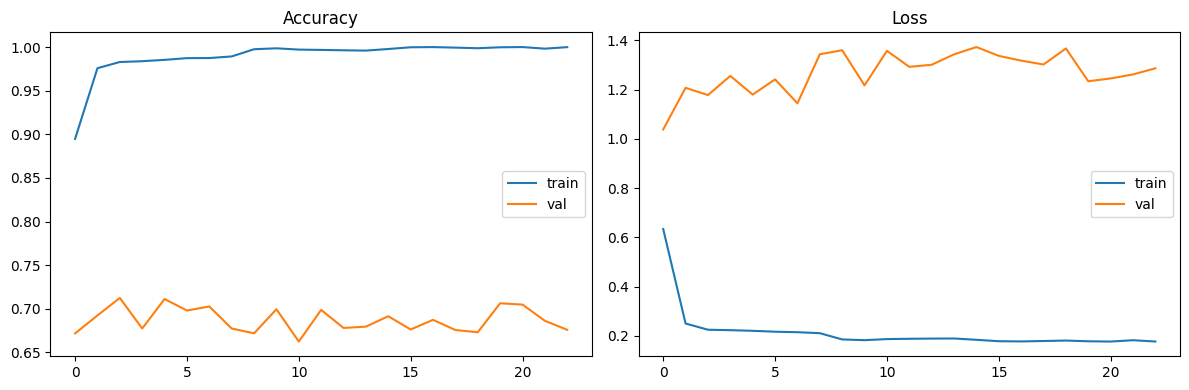

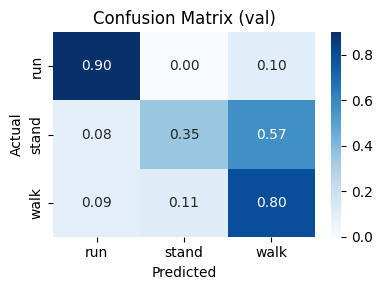

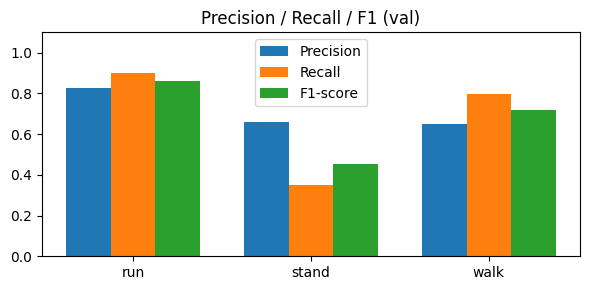

In [3]:
# 학습 결과 시각화 그래프

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── 1. 기존 Accuracy / Loss 그래프 ──────────────────
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.tight_layout(); plt.show()

# ── 2. Confusion Matrix (혼동 행렬) ─────────────────
y_pred     = model.predict(X_val, verbose=0)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true_cls = y_val

cm = confusion_matrix(y_true_cls, y_pred_cls)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # 비율로 정규화

plt.figure(figsize=(4, 3))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix (val)')
plt.tight_layout(); plt.show()

# ── 3. 클래스별 Precision / Recall / F1 ─────────────
report = classification_report(y_true_cls, y_pred_cls,
                                target_names=le.classes_,
                                output_dict=True)

classes    = le.classes_
precision  = [report[c]['precision'] for c in classes]
recall     = [report[c]['recall']    for c in classes]
f1         = [report[c]['f1-score']  for c in classes]

x = np.arange(len(classes))
w = 0.25

plt.figure(figsize=(6, 3))
plt.bar(x - w, precision, w, label='Precision')
plt.bar(x,     recall,    w, label='Recall')
plt.bar(x + w, f1,        w, label='F1-score')
plt.xticks(x, classes)
plt.ylim(0, 1.1)
plt.title('Precision / Recall / F1 (val)')
plt.legend(); plt.tight_layout(); plt.show()